In [ ]:
!pip install yfinance 

In [ ]:
!pip install torch 

In [ ]:
!pip install torchvision 

In [ ]:
!pip install torchaudio --index-url https://download.pytorch.org/whl/cu128

In [ ]:
!pip install scipy pandas matplotlib tqdm seaborn

In [ ]:
pip uninstall torch torchvision torchaudio -y

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.version.cuda)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

Using Device: cuda
NVIDIA GeForce RTX 5050 Laptop GPU




[*********************100%***********************]  6 of 6 completed


Ticker            AAPL        GME        NVDA         QQQ         SPY  \
Date                                                                    
2024-12-24  256.797211  31.139999  140.174072  526.621826  592.702087   
2024-12-26  257.612701  32.990002  139.884155  526.264038  592.741638   
2024-12-27  254.201370  32.200001  136.965118  519.268433  586.502075   
2024-12-30  250.829788  32.009998  137.444946  512.362183  579.809204   
2024-12-31  249.059464  31.340000  134.246017  508.009766  577.699768   

Ticker            TSLA  
Date                    
2024-12-24  462.279999  
2024-12-26  454.130005  
2024-12-27  431.660004  
2024-12-30  417.410004  
2024-12-31  403.839996  

Processing SPY


100%|██████████| 1700/1700 [06:40<00:00,  4.25it/s]



Processing QQQ


...


Processing NVDA


100%|██████████| 1700/1700 [03:49<00:00,  7.41it/s]



Processing GME


100%|██████████| 1700/1700 [03:51<00:00,  7.35it/s]



Experiment Finished.

  asset  alpha  beta  lambda  mean_return  volatility  kurtosis      skew  \
0   SPY    0.1 -0.15    0.05     0.004966    0.202543  0.002724 -0.009588   
1   SPY    0.1 -0.15    0.10     0.003293    0.202198 -0.018938 -0.009474   
2   SPY    0.1 -0.15    0.15     0.004783    0.204070 -0.010086  0.008842   
3   SPY    0.1 -0.15    0.20     0.004431    0.204523 -0.007382  0.000581   
4   SPY    0.1 -0.15    0.25     0.003924    0.204501 -0.025457  0.006646   

     VaR_95   CVaR_95  vol_cluster  GBM_mean   GBM_vol  GBM_kurtosis  \
0 -0.330750 -0.414276     0.002588  0.110771  0.210383       0.00799   
1 -0.331734 -0.414395     0.001109  0.110771  0.210383       0.00799   
2 -0.330506 -0.415457     0.005428  0.110771  0.210383       0.00799   
3 -0.332548 -0.417013    -0.004671  0.110771  0.210383       0.00799   
4 -0.332259 -0.415721    -0.001013  0.110771  0.210383       0.00799   

   GBM_skew   GBM_VaR  GBM_CVaR  GBM_vol_cluster  
0 -0.015427 -0.238079 -0.32547

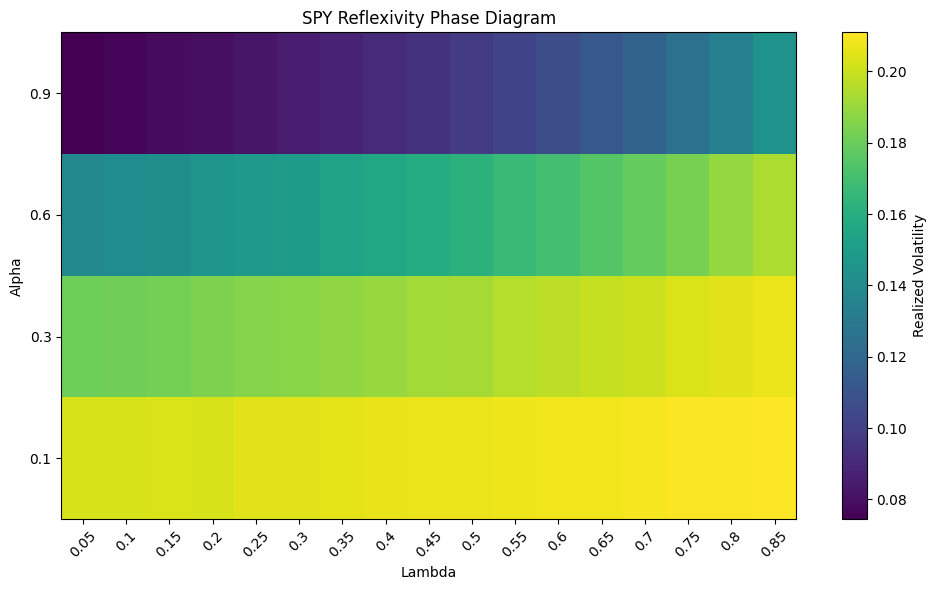

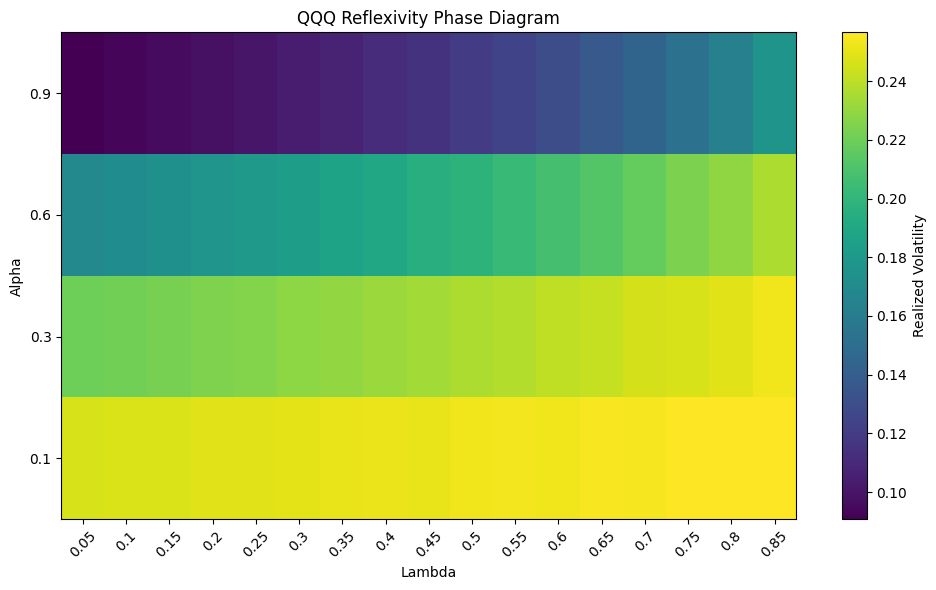

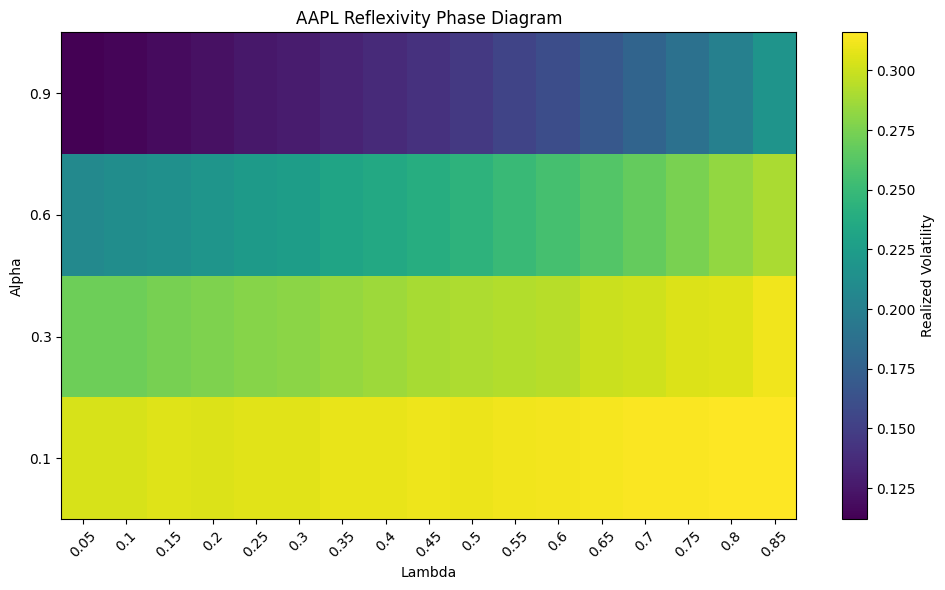

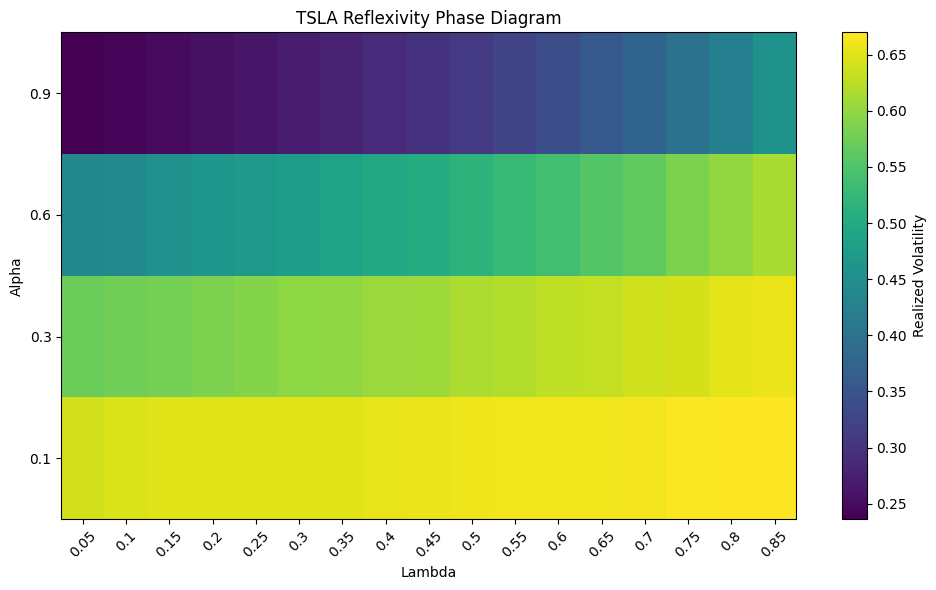

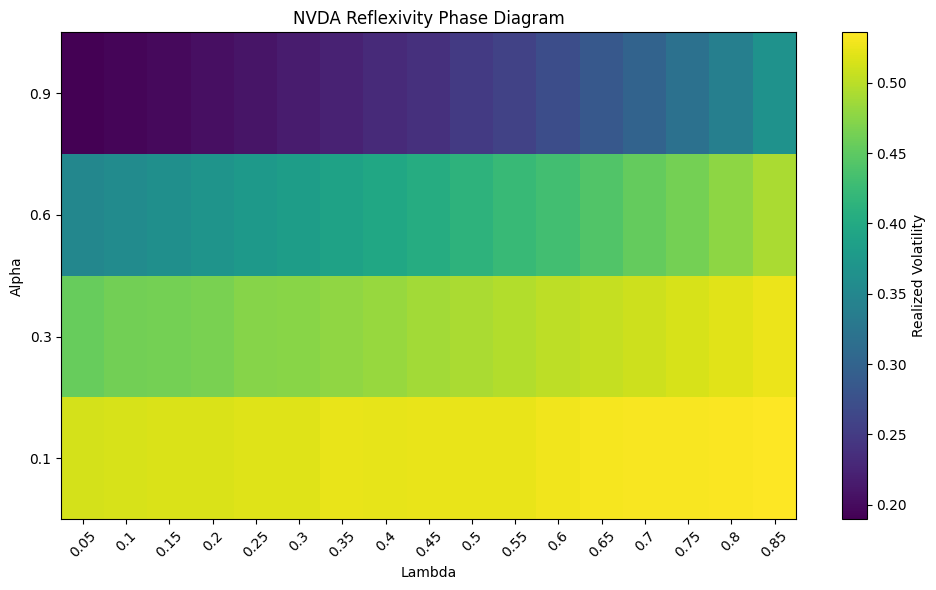

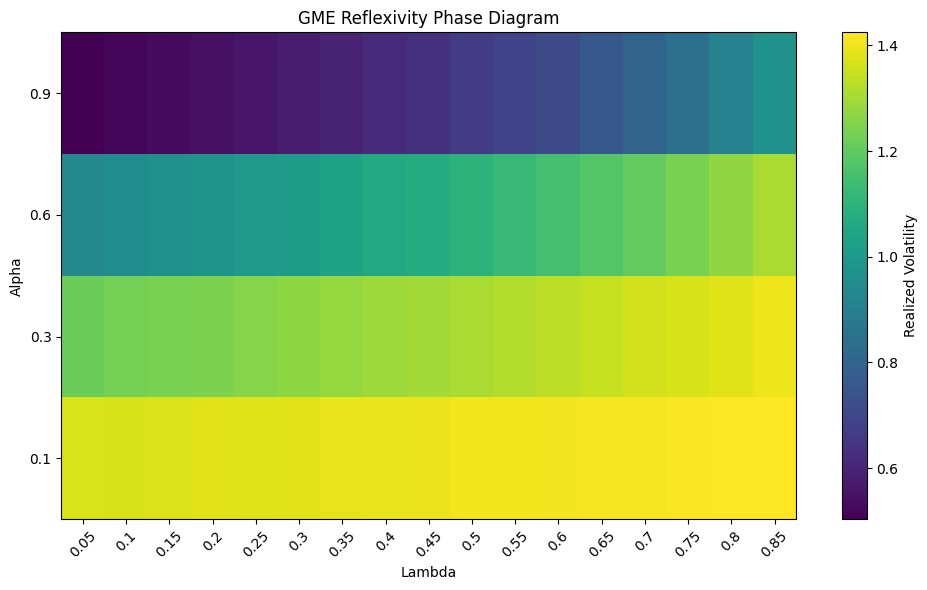

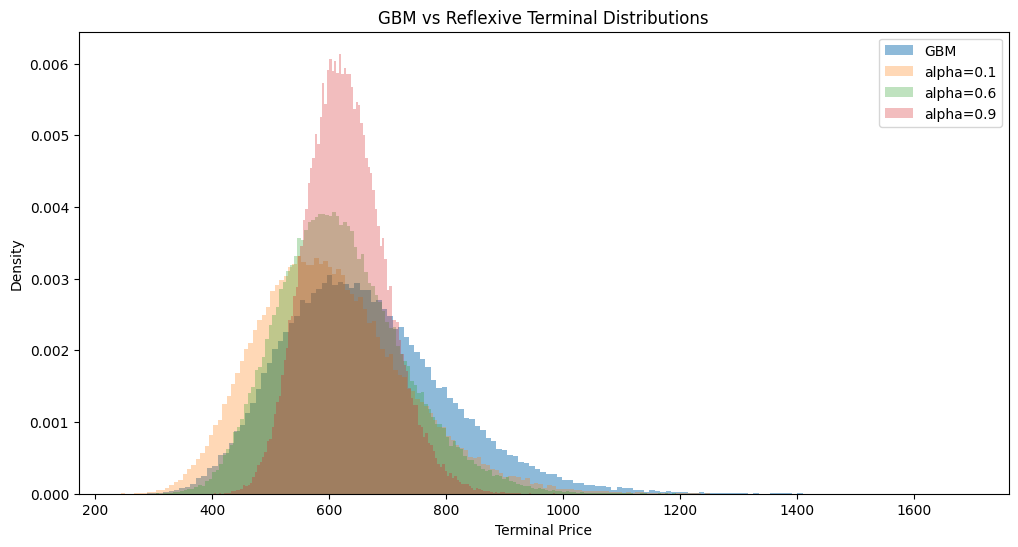

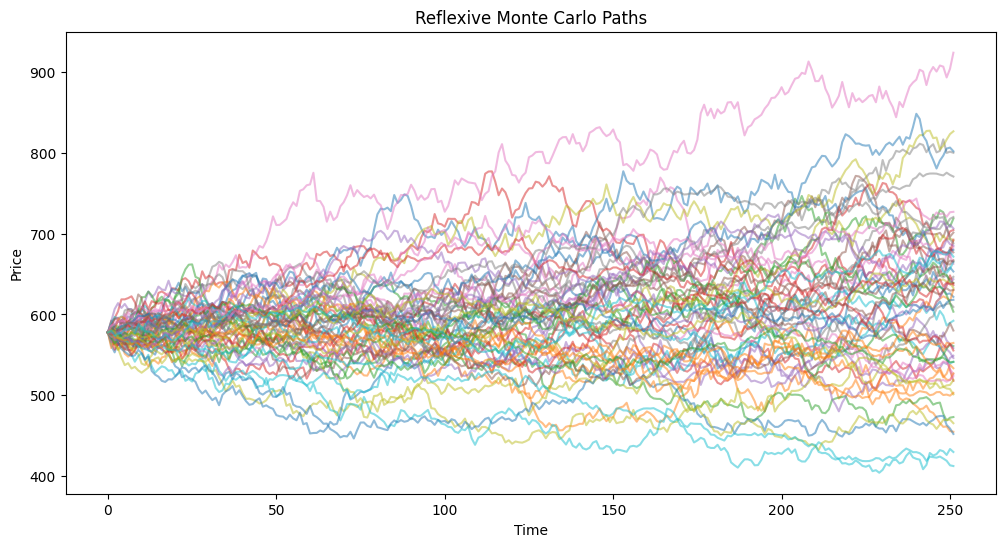

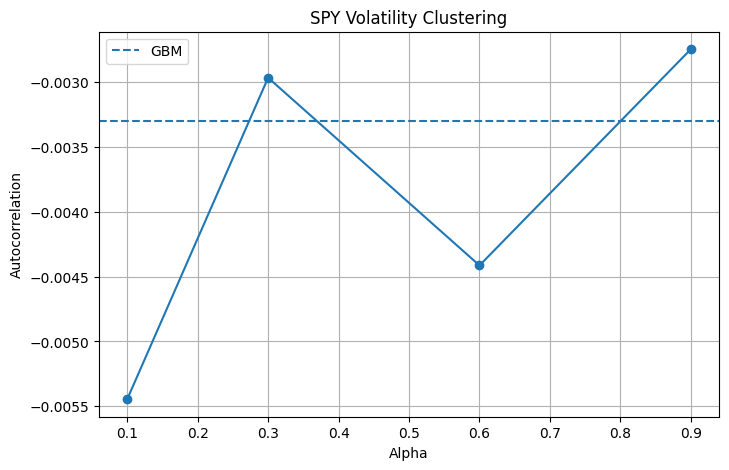

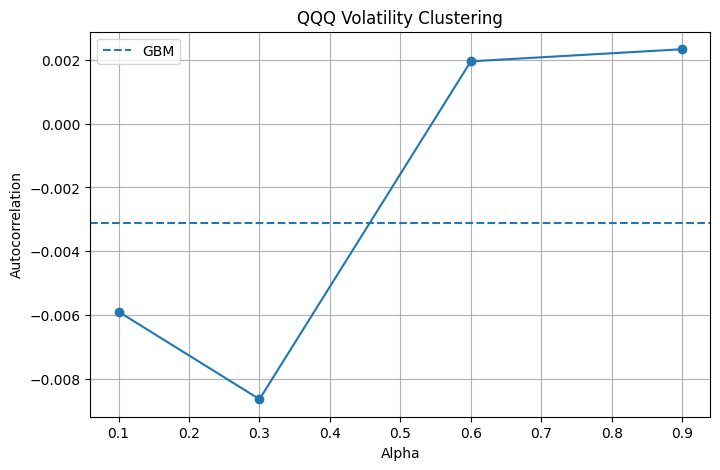

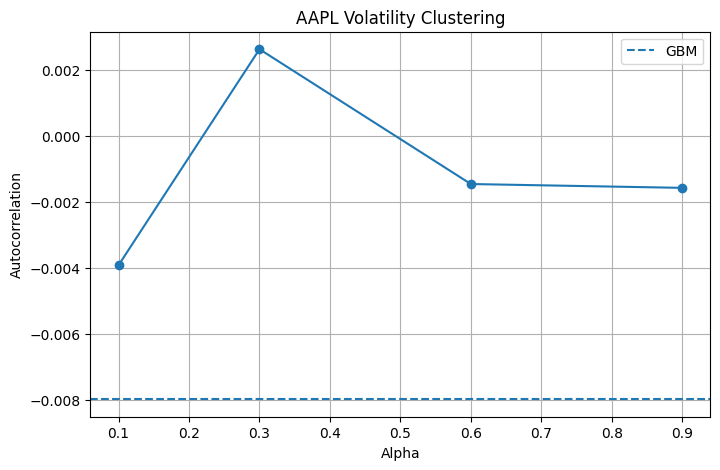

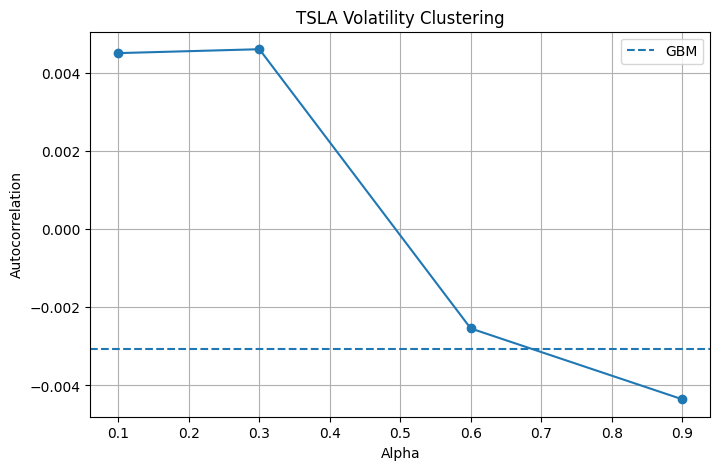

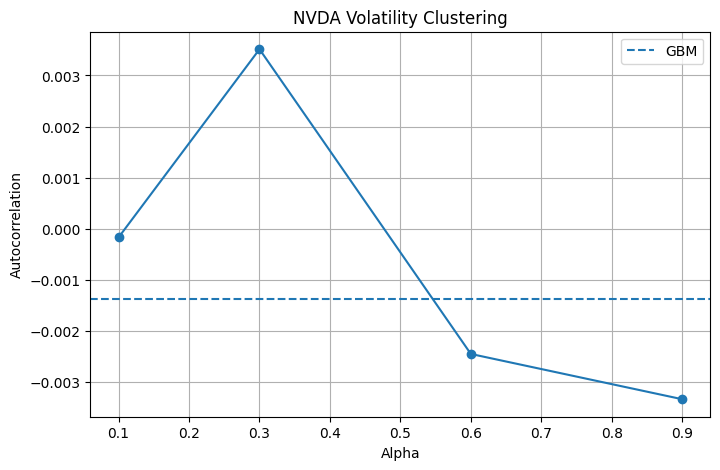

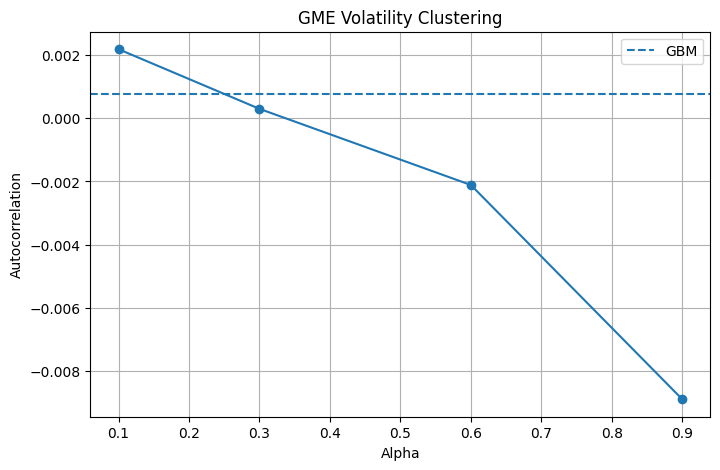

   asset  alpha  volatility  kurtosis    VaR_95  vol_cluster
0   AAPL    0.1    0.310126 -0.001276 -0.518260    -0.000052
1   AAPL    0.3    0.288965 -0.000328 -0.477258    -0.000173
2   AAPL    0.6    0.242975  0.000640 -0.389653    -0.000077
3   AAPL    0.9    0.149333  0.000343 -0.217418     0.000033
4    GME    0.1    1.396562  0.000557 -3.232056     0.000133
5    GME    0.3    1.300585 -0.000706 -2.947170    -0.000436
6    GME    0.6    1.094106  0.000131 -2.364823    -0.000027
7    GME    0.9    0.672348  0.000180 -1.301621     0.000035
8   NVDA    0.1    0.524358  0.000358 -0.960096    -0.000252
9   NVDA    0.3    0.488500  0.000150 -0.883158     0.000154
10  NVDA    0.6    0.410870  0.000032 -0.721250     0.000030
11  NVDA    0.9    0.252457  0.000811 -0.408554    -0.000032
12   QQQ    0.1    0.252063 -0.001651 -0.406542     0.000005
13   QQQ    0.3    0.234834 -0.000211 -0.374051    -0.000065
14   QQQ    0.6    0.197498  0.000047 -0.304690     0.000124
15   QQQ    0.9    0.121

In [1]:
# ============================================================
# Reflexive Black-Scholes vs Classical GBM
# GPU Accelerated Monte Carlo Framework
# ============================================================

# ============================================================
# INSTALLS (Uncomment if needed)
# ============================================================

# !pip install yfinance torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
# !pip install scipy pandas matplotlib tqdm seaborn

# ============================================================
# IMPORTS
# ============================================================

import torch
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from scipy.stats import kurtosis, skew
from tqdm import tqdm

# ============================================================
# DEVICE SETUP
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using Device: {device}")

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

# ============================================================
# CONFIGURATION
# ============================================================

assets = [
    "SPY",
    "QQQ",
    "AAPL",
    "TSLA",
    "NVDA",
    "GME"
]

alphas = [0.1, 0.3, 0.6, 0.9]

betas = np.linspace(-0.15, 0.15, 25)

lambdas = np.linspace(0.05, 0.85, 17)

epsilon = 0.02

risk_free_rate = 0.04

n_paths = 100000
n_steps = 252
T = 1.0

dt = T / n_steps

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

# ============================================================
# DOWNLOAD MARKET DATA
# ============================================================

print("\nDownloading market data...\n")

prices = yf.download(
    assets,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)["Close"]

returns = np.log(prices / prices.shift(1)).dropna()

print(prices.tail())

# ============================================================
# PARAMETER ESTIMATION
# ============================================================

mu_dict = {}
sigma_dict = {}
S0_dict = {}

for asset in assets:

    r = returns[asset]

    mu_dict[asset] = r.mean() * 252
    sigma_dict[asset] = r.std() * np.sqrt(252)
    S0_dict[asset] = prices[asset].iloc[-1]

# ============================================================
# GPU GBM SIMULATION
# ============================================================

def simulate_gbm_gpu(
    S0,
    mu,
    sigma,
    n_paths,
    n_steps,
    dt
):

    S0 = torch.tensor(S0, device=device, dtype=torch.float32)

    mu = torch.tensor(mu, device=device, dtype=torch.float32)

    sigma = torch.tensor(
        sigma,
        device=device,
        dtype=torch.float32
    )

    Z = torch.randn(
        (n_paths, n_steps - 1),
        device=device
    )

    drift = (
        (mu - 0.5 * sigma**2) * dt
    )

    diffusion = (
        sigma * np.sqrt(dt) * Z
    )

    log_returns = drift + diffusion

    log_returns = torch.cat(
        [
            torch.zeros(
                (n_paths, 1),
                device=device
            ),
            log_returns
        ],
        dim=1
    )

    cumulative = torch.cumsum(
        log_returns,
        dim=1
    )

    paths = S0 * torch.exp(cumulative)

    return paths

# ============================================================
# GPU REFLEXIVE MODEL
# ============================================================

def simulate_reflexive_gpu(
    S0,
    sigma0,
    alpha,
    beta,
    lambda_reflexive,
    epsilon,
    n_paths,
    n_steps,
    dt,
    window=20
):

    S0 = torch.tensor(
        S0,
        device=device,
        dtype=torch.float32
    )

    sigma0 = torch.tensor(
        sigma0,
        device=device,
        dtype=torch.float32
    )

    alpha = torch.tensor(
        alpha,
        device=device,
        dtype=torch.float32
    )

    beta = torch.tensor(
        beta,
        device=device,
        dtype=torch.float32
    )

    lambda_reflexive = torch.tensor(
        lambda_reflexive,
        device=device,
        dtype=torch.float32
    )

    # ====================================================
    # PATH STORAGE
    # ====================================================

    paths = torch.zeros(
        (n_paths, n_steps),
        device=device
    )

    paths[:, 0] = S0

    # ====================================================
    # INITIAL VOLATILITY
    # ====================================================

    sigma_t = torch.ones(
        n_paths,
        device=device
    ) * sigma0

    # ====================================================
    # VOLATILITY MEMORY
    # ====================================================

    vol_history = [sigma_t**2]

    # ====================================================
    # TIME LOOP
    # ====================================================

    for t in range(1, n_steps):

        # ================================================
        # RANDOM SHOCKS
        # ================================================

        Z = torch.randn(
            n_paths,
            device=device
        )

        # ================================================
        # MOVING-AVERAGE VOLATILITY
        # ================================================

        recent_history = vol_history[-window:]

        avg_sigma_sq = torch.mean(
            torch.stack(recent_history),
            dim=0
        )

        # ================================================
        # REFLEXIVE VOLATILITY
        # ================================================

        sigma_t = torch.sqrt(
            sigma0**2
            +
            lambda_reflexive
            * alpha
            * avg_sigma_sq
        )

        # store for future memory
        vol_history.append(sigma_t**2)

        # ================================================
        # DRIFT
        # ================================================

        drift = (
            risk_free_rate
            +
            beta * alpha
        )

        # ================================================
        # DIFFUSION
        # ================================================

        diffusion = (
            sigma_t
            *
            torch.sqrt(
                (1 - alpha)
                + epsilon
            )
        )

        # ================================================
        # EULER STEP
        # ================================================

        increment = (
            (drift - 0.5 * diffusion**2)
            * dt
            +
            diffusion
            * np.sqrt(dt)
            * Z
        )

        paths[:, t] = (
            paths[:, t - 1]
            * torch.exp(increment)
        )

    return paths

# ============================================================
# VOLATILITY CLUSTERING
# ============================================================

def volatility_clustering_metric(
    returns
):

    squared = returns**2

    autocorr = np.corrcoef(
        squared[:-1],
        squared[1:]
    )[0, 1]

    return autocorr

# ============================================================
# RESULTS STORAGE
# ============================================================

results = []

# ============================================================
# MAIN EXPERIMENT
# ============================================================

for asset in assets:

    print(f"\n==============================")
    print(f"Processing {asset}")
    print(f"==============================")

    S0 = S0_dict[asset]

    mu = mu_dict[asset]

    sigma = sigma_dict[asset]

    # ========================================================
    # STANDARD GBM
    # ========================================================

    gbm_paths = simulate_gbm_gpu(
        S0,
        mu,
        sigma,
        n_paths,
        n_steps,
        dt
    )

    gbm_terminal = (
        gbm_paths[:, -1]
        .detach()
        .cpu()
        .numpy()
    )

    gbm_returns = np.log(
        gbm_terminal / S0
    )

    gbm_vol_cluster = volatility_clustering_metric(
        gbm_returns
    )

    gbm_stats = {

        "mean":
            np.mean(gbm_returns),

        "std":
            np.std(gbm_returns),

        "kurtosis":
            kurtosis(gbm_returns),

        "skew":
            skew(gbm_returns),

        "VaR_95":
            np.percentile(
                gbm_returns,
                5
            ),

        "CVaR_95":
            gbm_returns[
                gbm_returns
                <=
                np.percentile(
                    gbm_returns,
                    5
                )
            ].mean(),

        "vol_cluster":
            gbm_vol_cluster
    }

    # ========================================================
    # REFLEXIVE MODELS
    # ========================================================

    total_iter = (
        len(alphas)
        * len(betas)
        * len(lambdas)
    )

    pbar = tqdm(total=total_iter)

    for alpha in alphas:

        for beta in betas:

            for lambda_reflexive in lambdas:

                paths = simulate_reflexive_gpu(
                    S0=S0,
                    sigma0=sigma,
                    alpha=alpha,
                    beta=beta,
                    lambda_reflexive=lambda_reflexive,
                    epsilon=epsilon,
                    n_paths=n_paths,
                    n_steps=n_steps,
                    dt=dt
                )

                terminal = (
                    paths[:, -1]
                    .detach()
                    .cpu()
                    .numpy()
                )

                reflexive_returns = np.log(
                    terminal / S0
                )

                vol_cluster = (
                    volatility_clustering_metric(
                        reflexive_returns
                    )
                )

                results.append({

                    "asset":
                        asset,

                    "alpha":
                        alpha,

                    "beta":
                        beta,

                    "lambda":
                        lambda_reflexive,

                    "mean_return":
                        np.mean(
                            reflexive_returns
                        ),

                    "volatility":
                        np.std(
                            reflexive_returns
                        ),

                    "kurtosis":
                        kurtosis(
                            reflexive_returns
                        ),

                    "skew":
                        skew(
                            reflexive_returns
                        ),

                    "VaR_95":
                        np.percentile(
                            reflexive_returns,
                            5
                        ),

                    "CVaR_95":
                        reflexive_returns[
                            reflexive_returns
                            <=
                            np.percentile(
                                reflexive_returns,
                                5
                            )
                        ].mean(),

                    "vol_cluster":
                        vol_cluster,

                    "GBM_mean":
                        gbm_stats["mean"],

                    "GBM_vol":
                        gbm_stats["std"],

                    "GBM_kurtosis":
                        gbm_stats["kurtosis"],

                    "GBM_skew":
                        gbm_stats["skew"],

                    "GBM_VaR":
                        gbm_stats["VaR_95"],

                    "GBM_CVaR":
                        gbm_stats["CVaR_95"],

                    "GBM_vol_cluster":
                        gbm_stats["vol_cluster"]
                })

                pbar.update(1)

    pbar.close()

# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

print("\nExperiment Finished.\n")

print(results_df.head())

# ============================================================
# SAVE RESULTS
# ============================================================

results_df.to_csv(
    "reflexive_experiment_results.csv",
    index=False
)

print("\nResults saved.\n")

# ============================================================
# PHASE DIAGRAM
# ============================================================

print("\nGenerating phase diagrams...\n")

for asset in assets:

    subset = results_df[
        (results_df["asset"] == asset)
        &
        (results_df["beta"] == 0.0)
    ]

    pivot = subset.pivot_table(
        values="volatility",
        index="alpha",
        columns="lambda"
    )

    plt.figure(figsize=(10, 6))

    plt.imshow(
        pivot,
        aspect="auto",
        origin="lower"
    )

    plt.colorbar(
        label="Realized Volatility"
    )

    plt.xticks(
        ticks=np.arange(len(lambdas)),
        labels=np.round(lambdas, 2),
        rotation=45
    )

    plt.yticks(
        ticks=np.arange(len(alphas)),
        labels=alphas
    )

    plt.xlabel("Lambda")

    plt.ylabel("Alpha")

    plt.title(
        f"{asset} Reflexivity Phase Diagram"
    )

    plt.tight_layout()

    plt.show()

# ============================================================
# TERMINAL DISTRIBUTION COMPARISON
# ============================================================

asset = "SPY"

S0 = S0_dict[asset]

mu = mu_dict[asset]

sigma = sigma_dict[asset]

# ============================================================
# GBM
# ============================================================

gbm_paths = simulate_gbm_gpu(
    S0,
    mu,
    sigma,
    n_paths,
    n_steps,
    dt
)

gbm_terminal = (
    gbm_paths[:, -1]
    .detach()
    .cpu()
    .numpy()
)

plt.figure(figsize=(12, 6))

plt.hist(
    gbm_terminal,
    bins=150,
    density=True,
    alpha=0.5,
    label="GBM"
)

# ============================================================
# REFLEXIVE
# ============================================================

for alpha in [0.1, 0.6, 0.9]:

    paths = simulate_reflexive_gpu(
        S0=S0,
        sigma0=sigma,
        alpha=alpha,
        beta=0.05,
        lambda_reflexive=0.6,
        epsilon=epsilon,
        n_paths=n_paths,
        n_steps=n_steps,
        dt=dt
    )

    terminal = (
        paths[:, -1]
        .detach()
        .cpu()
        .numpy()
    )

    plt.hist(
        terminal,
        bins=150,
        density=True,
        alpha=0.3,
        label=f"alpha={alpha}"
    )

plt.legend()

plt.title(
    "GBM vs Reflexive Terminal Distributions"
)

plt.xlabel("Terminal Price")

plt.ylabel("Density")

plt.show()

# ============================================================
# SAMPLE PATHS
# ============================================================

plt.figure(figsize=(12, 6))

for alpha in alphas:

    paths = simulate_reflexive_gpu(
        S0=S0,
        sigma0=sigma,
        alpha=alpha,
        beta=0.05,
        lambda_reflexive=0.6,
        epsilon=epsilon,
        n_paths=100,
        n_steps=n_steps,
        dt=dt
    )

    paths_np = (
        paths
        .detach()
        .cpu()
        .numpy()
    )

    for i in range(15):

        plt.plot(
            paths_np[i],
            alpha=0.5
        )

plt.title(
    "Reflexive Monte Carlo Paths"
)

plt.xlabel("Time")

plt.ylabel("Price")

plt.show()

# ============================================================
# VOLATILITY CLUSTERING COMPARISON
# ============================================================

for asset in assets:

    subset = results_df[
        (results_df["asset"] == asset)
        &
        (results_df["beta"] == 0.0)
        &
        (results_df["lambda"] == 0.6)
    ]

    plt.figure(figsize=(8,5))

    plt.plot(
        subset["alpha"],
        subset["vol_cluster"],
        marker='o'
    )

    plt.axhline(
        subset["GBM_vol_cluster"].iloc[0],
        linestyle="--",
        label="GBM"
    )

    plt.title(
        f"{asset} Volatility Clustering"
    )

    plt.xlabel("Alpha")

    plt.ylabel("Autocorrelation")

    plt.legend()

    plt.grid(True)

    plt.show()

# ============================================================
# SUMMARY TABLE
# ============================================================

summary = results_df.groupby(
    ["asset", "alpha"]
).agg({

    "volatility": "mean",

    "kurtosis": "mean",

    "VaR_95": "mean",

    "vol_cluster": "mean"

}).reset_index()

print(summary)

summary.to_csv(
    "summary_statistics.csv",
    index=False
)

print("\nAll done.\n")


VALIDATING SPY


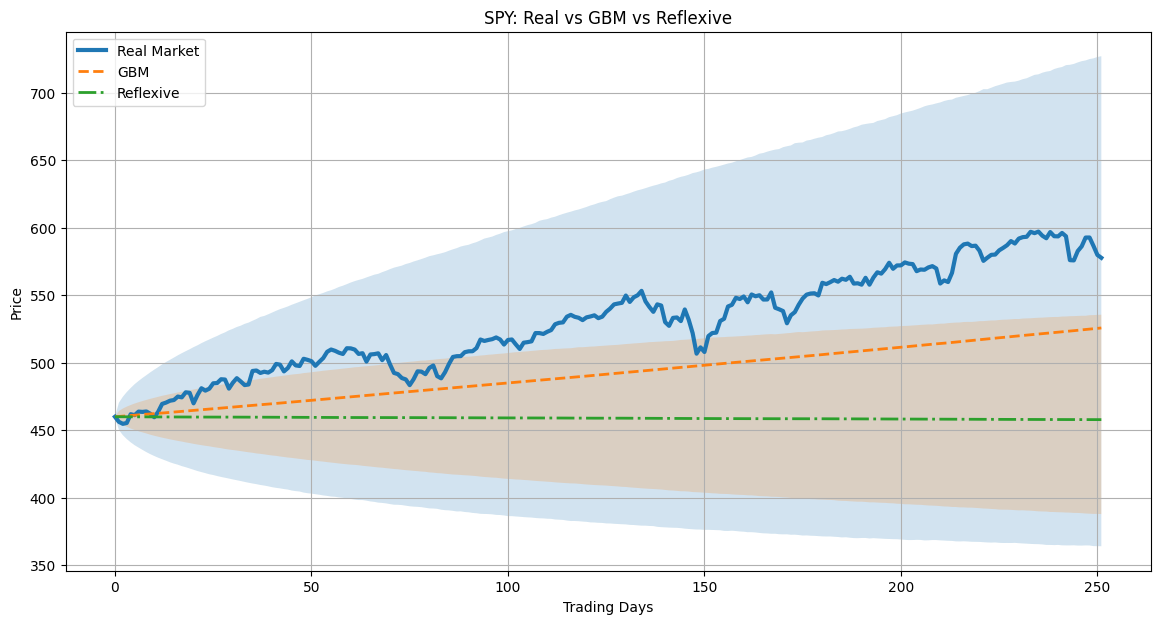


VALIDATING QQQ


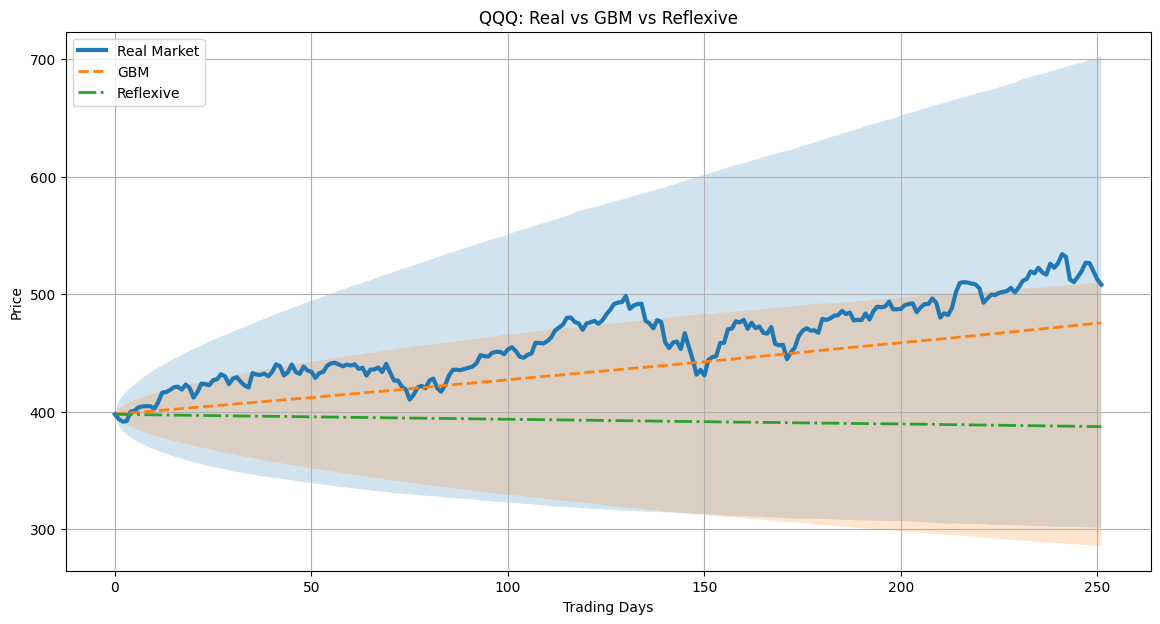


VALIDATING AAPL


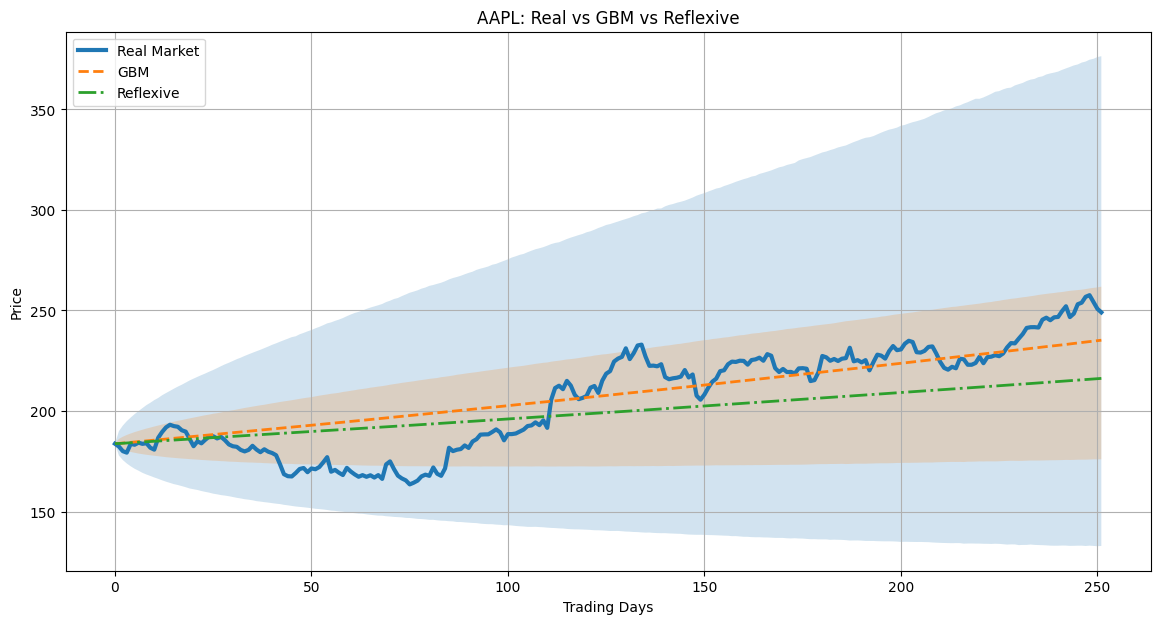


VALIDATING TSLA


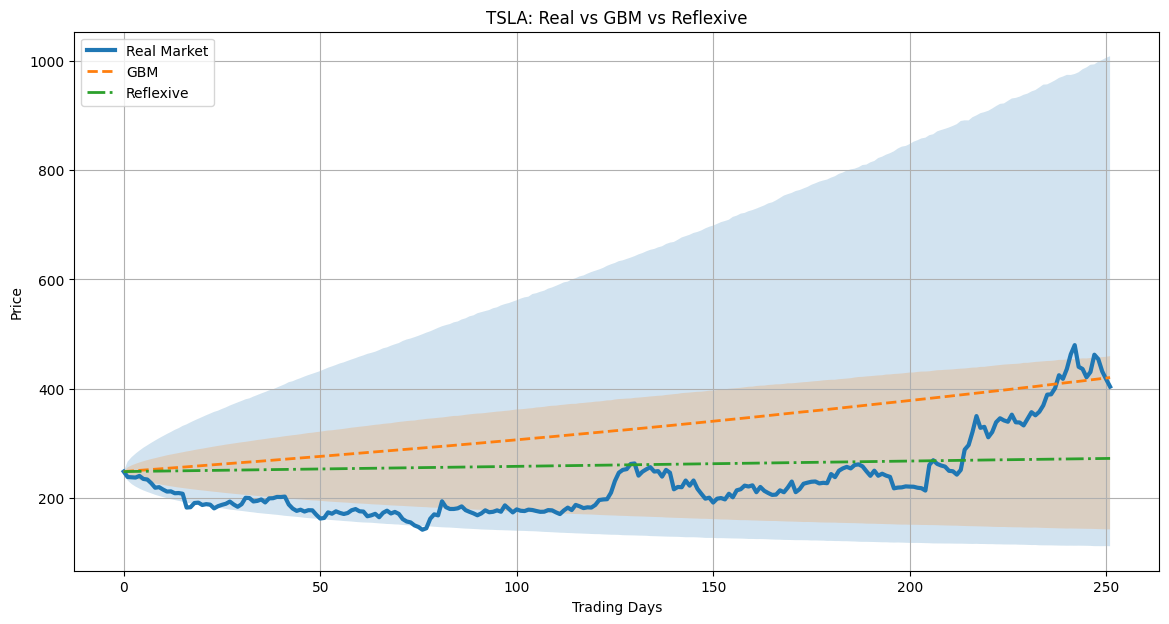


VALIDATING NVDA


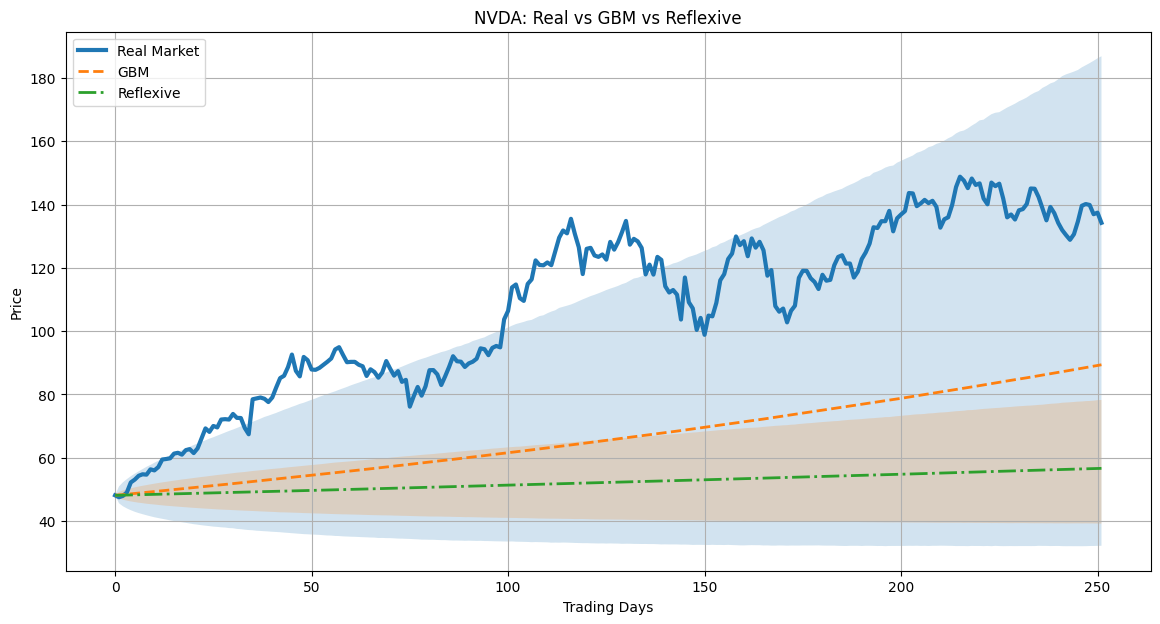


VALIDATING GME


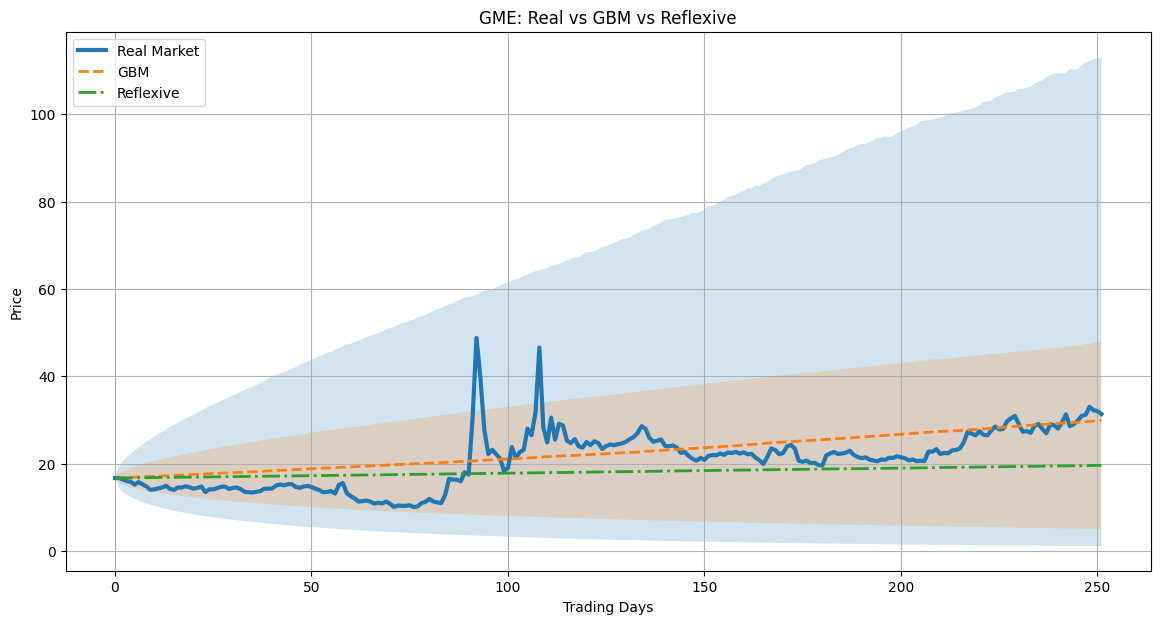


FULL EMPIRICAL COMPARISON

  Asset    GBM_RMSE   REF_RMSE    GBM_MAE    REF_MAE   GBM_MAPE   REF_MAPE  \
0   SPY   42.629789  80.526990  37.877132  70.943350   6.929719  12.944669   
1   QQQ   29.213728  76.816692  25.516508  68.042049   5.391102  14.301297   
2  AAPL   14.106545  18.643207  11.061560  16.236226   5.739576   7.812295   
3  TSLA  107.100308  72.401459  99.272966  62.189778  48.626280  28.738371   
4  NVDA   44.495483  60.730820  41.134028  55.508133  36.245785  48.218829   
5   GME    5.129668   6.484923   3.912876   5.180861  22.653373  24.795936   

   GBM_Corr  REF_Corr  GBM_Directional_Acc  ...  REF_Kurtosis  Real_Skew  \
0  0.967812 -0.967018             0.589641  ...     -0.009909  -0.572162   
1  0.919538 -0.919595             0.589641  ...     -0.013909  -0.465700   
2  0.895776  0.894769             0.565737  ...      0.020581   0.390319   
3  0.761187  0.724168             0.505976  ...      0.013686   0.572169   
4  0.900249  0.913564             0.557769  .

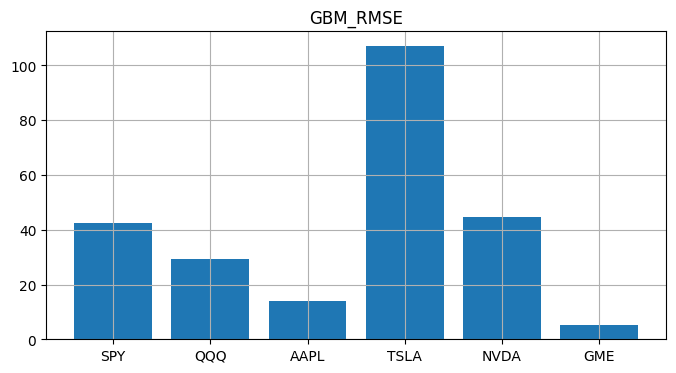

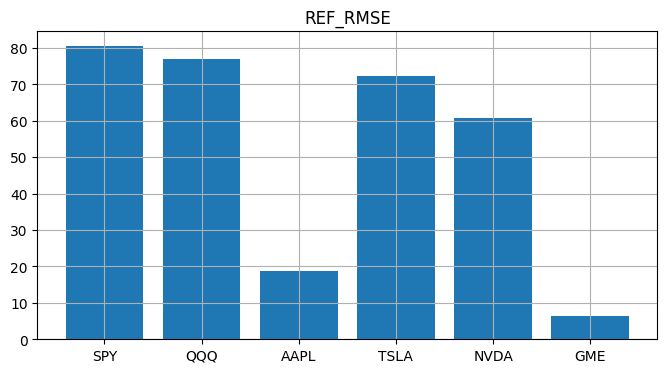

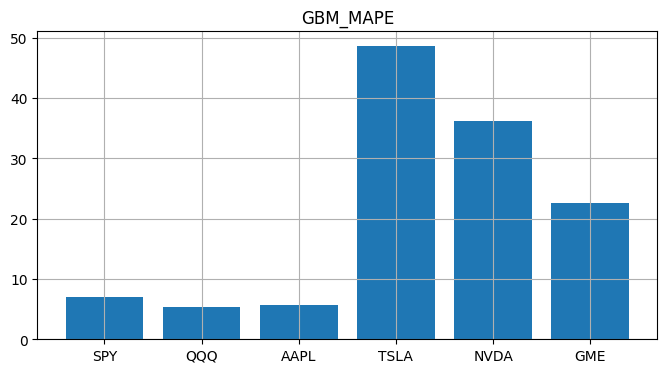

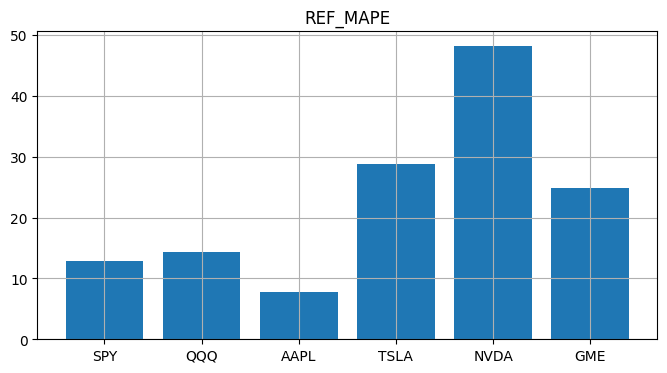

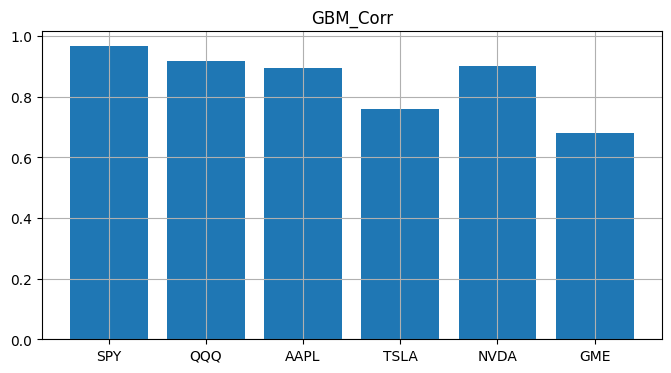

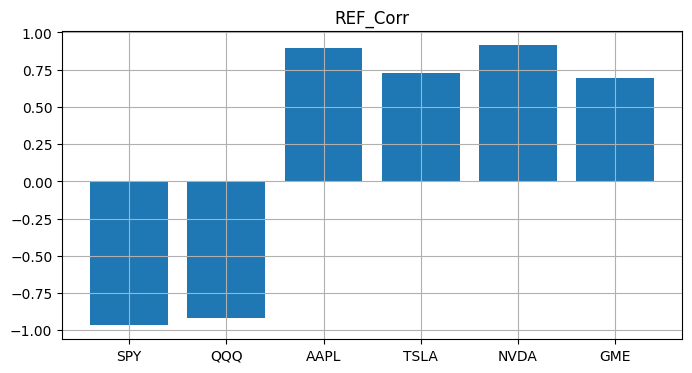

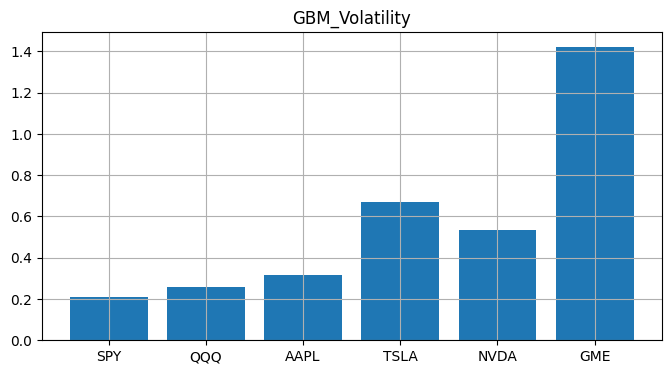

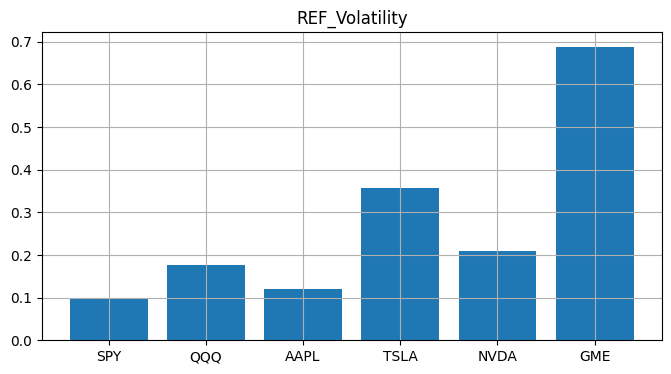

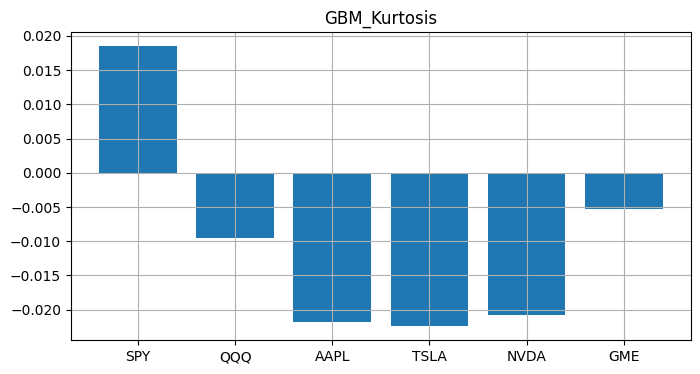

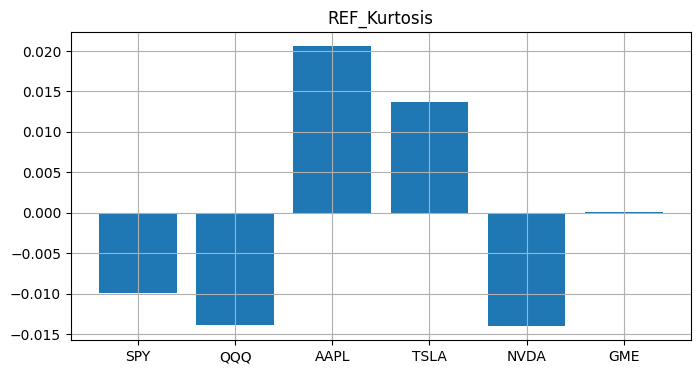


MODEL WINNER SUMMARY

  Asset Better_RMSE_Model Better_MAPE_Model Higher_Correlation
0   SPY               GBM               GBM                GBM
1   QQQ               GBM               GBM                GBM
2  AAPL               GBM               GBM                GBM
3  TSLA         Reflexive         Reflexive                GBM
4  NVDA               GBM               GBM          Reflexive
5   GME               GBM               GBM          Reflexive


In [5]:
# ============================================================
# REAL vs GBM vs REFLEXIVE
# FULL EMPIRICAL VALIDATION FRAMEWORK
# ============================================================

# This section compares:
# 1. Real historical prices
# 2. Classical GBM
# 3. Reflexive model
#
# Metrics:
# - RMSE
# - MAE
# - MAPE
# - Volatility
# - Kurtosis
# - Skewness
# - VaR
# - CVaR
# - Correlation with real prices
# - Directional Accuracy
#
# Assets:
# SPY, QQQ, AAPL, TSLA, XOM
#
# ============================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

comparison_results = []

# ============================================================
# LOOP THROUGH ASSETS
# ============================================================

for asset in assets:

    print(f"\n====================================")
    print(f"VALIDATING {asset}")
    print(f"====================================")

    # ========================================================
    # REAL MARKET DATA
    # ========================================================

    historical_prices = prices[asset].dropna()

    # last 252 trading days
    real_path = historical_prices.values[-252:]

    time_axis = np.arange(len(real_path))

    S0 = real_path[0]

    mu = mu_dict[asset]

    sigma = sigma_dict[asset]

    chosen_alpha = 0.9

    # ========================================================
    # SELECT BEST BETA + LAMBDA
    # ========================================================

    asset_subset = results_df[
        (results_df["asset"] == asset)
        &
        (results_df["alpha"] == chosen_alpha)
    ]

    best_row = asset_subset.loc[
        asset_subset["vol_cluster"].idxmax()
    ]

    best_beta = best_row["beta"]

    best_lambda = best_row["lambda"]

    # ========================================================
    # GBM SIMULATION
    # ========================================================

    gbm_paths = simulate_gbm_gpu(
        S0=S0,
        mu=mu,
        sigma=sigma,
        n_paths=n_paths,
        n_steps=252,
        dt=dt
    )

    gbm_np = (
        gbm_paths
        .detach()
        .cpu()
        .numpy()
    )

    gbm_mean = gbm_np.mean(axis=0)

    gbm_lower = np.percentile(
        gbm_np,
        5,
        axis=0
    )

    gbm_upper = np.percentile(
        gbm_np,
        95,
        axis=0
    )

    # ========================================================
    # REFLEXIVE MODEL
    # ========================================================

    reflexive_paths = simulate_reflexive_gpu(
        S0=S0,
        sigma0=sigma,
        alpha=chosen_alpha,
        beta=best_beta,
        lambda_reflexive=best_lambda,
        epsilon=epsilon,
        n_paths=n_paths,
        n_steps=252,
        dt=dt
    )

    ref_np = (
        reflexive_paths
        .detach()
        .cpu()
        .numpy()
    )

    ref_mean = ref_np.mean(axis=0)

    ref_lower = np.percentile(
        ref_np,
        5,
        axis=0
    )

    ref_upper = np.percentile(
        ref_np,
        95,
        axis=0
    )

    # ========================================================
    # RETURNS
    # ========================================================

    real_returns = np.diff(
        np.log(real_path)
    )

    gbm_returns = np.log(
        gbm_np[:, -1] / gbm_np[:, 0]
    )

    ref_returns = np.log(
        ref_np[:, -1] / ref_np[:, 0]
    )

    # ========================================================
    # ERROR METRICS
    # ========================================================

    gbm_rmse = np.sqrt(
        mean_squared_error(
            real_path,
            gbm_mean
        )
    )

    ref_rmse = np.sqrt(
        mean_squared_error(
            real_path,
            ref_mean
        )
    )

    gbm_mae = mean_absolute_error(
        real_path,
        gbm_mean
    )

    ref_mae = mean_absolute_error(
        real_path,
        ref_mean
    )

    gbm_mape = np.mean(
        np.abs(
            (real_path - gbm_mean)
            / real_path
        )
    ) * 100

    ref_mape = np.mean(
        np.abs(
            (real_path - ref_mean)
            / real_path
        )
    ) * 100

    # ========================================================
    # CORRELATION
    # ========================================================

    gbm_corr = np.corrcoef(
        real_path,
        gbm_mean
    )[0,1]

    ref_corr = np.corrcoef(
        real_path,
        ref_mean
    )[0,1]

    # ========================================================
    # DIRECTIONAL ACCURACY
    # ========================================================

    real_direction = np.sign(
        np.diff(real_path)
    )

    gbm_direction = np.sign(
        np.diff(gbm_mean)
    )

    ref_direction = np.sign(
        np.diff(ref_mean)
    )

    gbm_directional_acc = np.mean(
        real_direction
        ==
        gbm_direction
    )

    ref_directional_acc = np.mean(
        real_direction
        ==
        ref_direction
    )

    # ========================================================
    # DISTRIBUTIONAL METRICS
    # ========================================================

    gbm_vol = np.std(gbm_returns)

    ref_vol = np.std(ref_returns)

    real_vol = np.std(real_returns)

    gbm_kurt = kurtosis(gbm_returns)

    ref_kurt = kurtosis(ref_returns)

    real_kurt = kurtosis(real_returns)

    gbm_skew = skew(gbm_returns)

    ref_skew = skew(ref_returns)

    real_skew = skew(real_returns)

    # ========================================================
    # VaR / CVaR
    # ========================================================

    gbm_var = np.percentile(
        gbm_returns,
        5
    )

    ref_var = np.percentile(
        ref_returns,
        5
    )

    real_var = np.percentile(
        real_returns,
        5
    )

    gbm_cvar = gbm_returns[
        gbm_returns <= gbm_var
    ].mean()

    ref_cvar = ref_returns[
        ref_returns <= ref_var
    ].mean()

    real_cvar = real_returns[
        real_returns <= real_var
    ].mean()

    # ========================================================
    # STORE RESULTS
    # ========================================================

    comparison_results.append({

        "Asset": asset,

        # ====================================================
        # RMSE
        # ====================================================

        "GBM_RMSE": gbm_rmse,
        "REF_RMSE": ref_rmse,

        # ====================================================
        # MAE
        # ====================================================

        "GBM_MAE": gbm_mae,
        "REF_MAE": ref_mae,

        # ====================================================
        # MAPE
        # ====================================================

        "GBM_MAPE": gbm_mape,
        "REF_MAPE": ref_mape,

        # ====================================================
        # CORRELATION
        # ====================================================

        "GBM_Corr": gbm_corr,
        "REF_Corr": ref_corr,

        # ====================================================
        # DIRECTIONAL ACCURACY
        # ====================================================

        "GBM_Directional_Acc":
            gbm_directional_acc,

        "REF_Directional_Acc":
            ref_directional_acc,

        # ====================================================
        # VOLATILITY
        # ====================================================

        "Real_Volatility":
            real_vol,

        "GBM_Volatility":
            gbm_vol,

        "REF_Volatility":
            ref_vol,

        # ====================================================
        # KURTOSIS
        # ====================================================

        "Real_Kurtosis":
            real_kurt,

        "GBM_Kurtosis":
            gbm_kurt,

        "REF_Kurtosis":
            ref_kurt,

        # ====================================================
        # SKEWNESS
        # ====================================================

        "Real_Skew":
            real_skew,

        "GBM_Skew":
            gbm_skew,

        "REF_Skew":
            ref_skew,

        # ====================================================
        # VaR
        # ====================================================

        "Real_VaR":
            real_var,

        "GBM_VaR":
            gbm_var,

        "REF_VaR":
            ref_var,

        # ====================================================
        # CVaR
        # ====================================================

        "Real_CVaR":
            real_cvar,

        "GBM_CVaR":
            gbm_cvar,

        "REF_CVaR":
            ref_cvar
    })

    # ========================================================
    # PLOT
    # ========================================================

    plt.figure(figsize=(14,7))

    # REAL
    plt.plot(
        time_axis,
        real_path,
        linewidth=3,
        label="Real Market"
    )

    # GBM
    plt.plot(
        time_axis,
        gbm_mean,
        linestyle="--",
        linewidth=2,
        label="GBM"
    )

    plt.fill_between(
        time_axis,
        gbm_lower,
        gbm_upper,
        alpha=0.2
    )

    # REFLEXIVE
    plt.plot(
        time_axis,
        ref_mean,
        linestyle="-.",
        linewidth=2,
        label="Reflexive"
    )

    plt.fill_between(
        time_axis,
        ref_lower,
        ref_upper,
        alpha=0.2
    )

    plt.title(
        f"{asset}: Real vs GBM vs Reflexive"
    )

    plt.xlabel("Trading Days")

    plt.ylabel("Price")

    plt.legend()

    plt.grid(True)

    plt.show()

# ============================================================
# RESULTS DATAFRAME
# ============================================================

comparison_df = pd.DataFrame(
    comparison_results
)

print("\n================================================")
print("FULL EMPIRICAL COMPARISON")
print("================================================\n")

print(comparison_df)

# ============================================================
# SAVE
# ============================================================

comparison_df.to_csv(
    "empirical_validation_results.csv",
    index=False
)

print("\nSaved empirical validation results.\n")

# ============================================================
# SUMMARY HEATMAPS
# ============================================================

metrics_to_plot = [

    "GBM_RMSE",
    "REF_RMSE",

    "GBM_MAPE",
    "REF_MAPE",

    "GBM_Corr",
    "REF_Corr",

    "GBM_Volatility",
    "REF_Volatility",

    "GBM_Kurtosis",
    "REF_Kurtosis"
]

for metric in metrics_to_plot:

    plt.figure(figsize=(8,4))

    plt.bar(
        comparison_df["Asset"],
        comparison_df[metric]
    )

    plt.title(metric)

    plt.grid(True)

    plt.show()

# ============================================================
# FINAL MODEL COMPARISON TABLE
# ============================================================

summary_table = pd.DataFrame({

    "Asset":
        comparison_df["Asset"],

    "Better_RMSE_Model":
        np.where(
            comparison_df["REF_RMSE"]
            <
            comparison_df["GBM_RMSE"],
            "Reflexive",
            "GBM"
        ),

    "Better_MAPE_Model":
        np.where(
            comparison_df["REF_MAPE"]
            <
            comparison_df["GBM_MAPE"],
            "Reflexive",
            "GBM"
        ),

    "Higher_Correlation":
        np.where(
            comparison_df["REF_Corr"]
            >
            comparison_df["GBM_Corr"],
            "Reflexive",
            "GBM"
        )
})

print("\n================================================")
print("MODEL WINNER SUMMARY")
print("================================================\n")

print(summary_table)

summary_table.to_csv(
    "model_winner_summary.csv",
    index=False
)